In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('HR_comma_sep.csv')

In [3]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
sns.pairplot(df[['satisfaction_level','last_evaluation','number_project','average_montly_hours','time_spend_company','Work_accident','left','promotion_last_5years','Department','salary']])

In [5]:
left = df[df.left==1]
left.shape

(3571, 10)

In [6]:
retained = df[df.left==0]
retained.shape

(11428, 10)

In [7]:
df.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


In [11]:
correlation_with_left = df.corr(numeric_only=True)['left'].sort_values(ascending = False)#

print("Correlation of each column with 'left':")
print(correlation_with_left)

Correlation of each column with 'left':
left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


<Axes: xlabel='salary'>

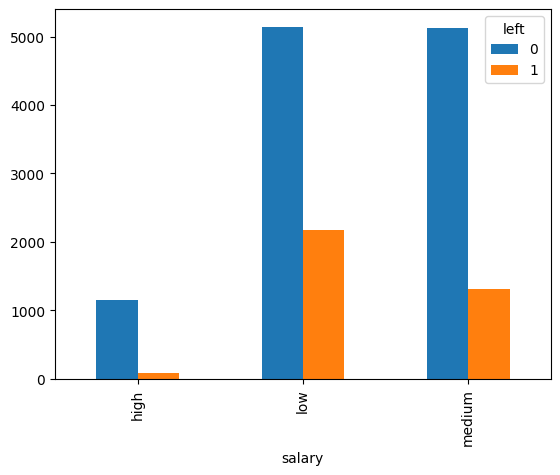

In [48]:
pd.crosstab(df.salary,df.left).plot(kind = 'bar')

<Axes: xlabel='Department'>

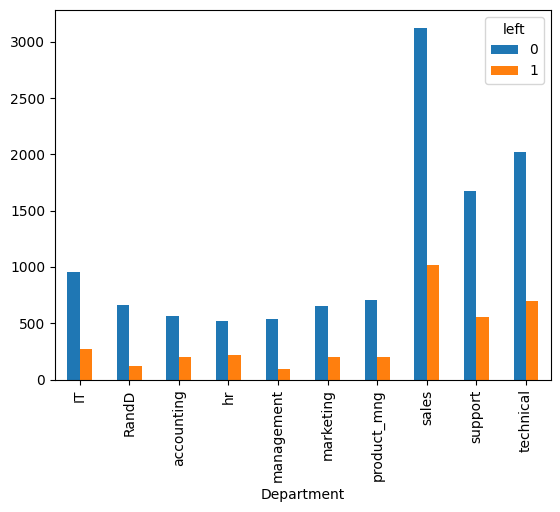

In [49]:
pd.crosstab(df.Department,df.left).plot(kind='bar')

In [86]:
subdf = df[['satisfaction_level','average_montly_hours','Work_accident','promotion_last_5years','salary']]
subdf.head()

,satisfaction_level,average_montly_hours,Work_accident,promotion_last_5years,salary
0,0.38,157,0,0,low
1,0.80,262,0,0,medium
2,0.11,272,0,0,medium
3,0.72,223,0,0,low
4,0.37,159,0,0,low


In [87]:
salary_dummies = pd.get_dummies(subdf.salary, prefix="salary")
salary_dummies

,salary_high,salary_low,salary_medium
0,False,True,False
1,False,False,True
2,False,False,True
3,False,True,False
4,False,True,False
...,...,...,...
14994,False,True,False
14995,False,True,False
14996,False,True,False
14997,False,True,False


In [88]:
df_with_dummies = pd.concat([subdf,salary_dummies],axis='columns')
df_with_dummies

,satisfaction_level,average_montly_hours,Work_accident,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,0,low,False,True,False
1,0.80,262,0,0,medium,False,False,True
2,0.11,272,0,0,medium,False,False,True
3,0.72,223,0,0,low,False,True,False
4,0.37,159,0,0,low,False,True,False
...,...,...,...,...,...,...,...,...
14994,0.40,151,0,0,low,False,True,False
14995,0.37,160,0,0,low,False,True,False
14996,0.37,143,0,0,low,False,True,False
14997,0.11,280,0,0,low,False,True,False


In [89]:
df_with_dummies.drop('salary',axis='columns',inplace=True)
df_with_dummies.head()

,satisfaction_level,average_montly_hours,Work_accident,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,0,False,True,False
1,0.80,262,0,0,False,False,True
2,0.11,272,0,0,False,False,True
3,0.72,223,0,0,False,True,False
4,0.37,159,0,0,False,True,False


In [90]:
x_data = df_with_dummies
y_data = df['left']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(x_data , y_data , test_size=0.2 , random_state = 42)

In [93]:
model = LogisticRegression(max_iter=15000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=15000)

In [94]:
model.predict(X_test[:100])

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [95]:
X_test[:10]

,satisfaction_level,average_montly_hours,Work_accident,promotion_last_5years,salary_high,salary_low,salary_medium
6723,0.65,226,1,0,False,False,True
6473,0.88,166,0,0,False,True,False
4679,0.69,214,0,0,False,True,False
862,0.41,154,0,0,False,True,False
7286,0.87,254,1,0,False,True,False
8127,0.72,224,0,0,False,True,False
3017,0.98,155,1,0,False,True,False
3087,0.17,280,0,0,False,True,False
6425,0.20,166,1,0,False,False,True
2250,0.16,258,0,0,False,False,True


In [96]:
model.score(X_test,y_test)

0.7673333333333333

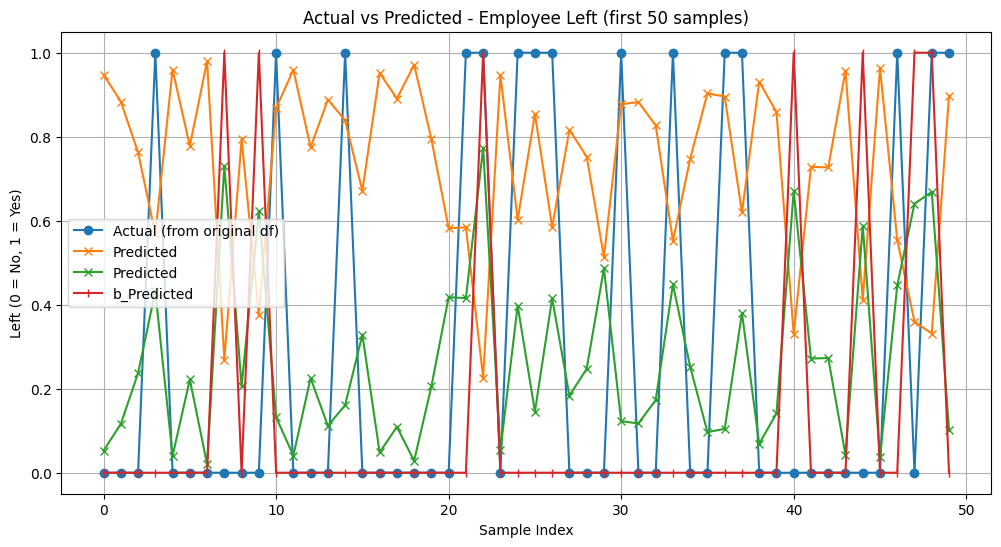

In [105]:
y_pred = model.predict_proba(X_test)
y_pred_binary = model.predict(X_test)

actual_from_df = df.loc[X_test.index, 'left'] 
count = 0



# Step 6: Plot
plt.figure(figsize=(12, 6))
plt.plot(actual_from_df.values[:50], label='Actual (from original df)', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.plot(y_pred_binary[:50], label='b_Predicted', marker='|')
plt.title('Actual vs Predicted - Employee Left (first 50 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Left (0 = No, 1 = Yes)')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
y_pred.shape

(3000,)

In [84]:
X_train.shape

(11999, 6)

In [85]:
X_test.shape

(3000, 6)

In [101]:
model.predict_proba(X_test)

array([[0.94745981, 0.05254019],
       [0.8838401 , 0.1161599 ],
       [0.76286137, 0.23713863],
       ...,
       [0.88528357, 0.11471643],
       [0.90204517, 0.09795483],
       [0.487878  , 0.512122  ]])